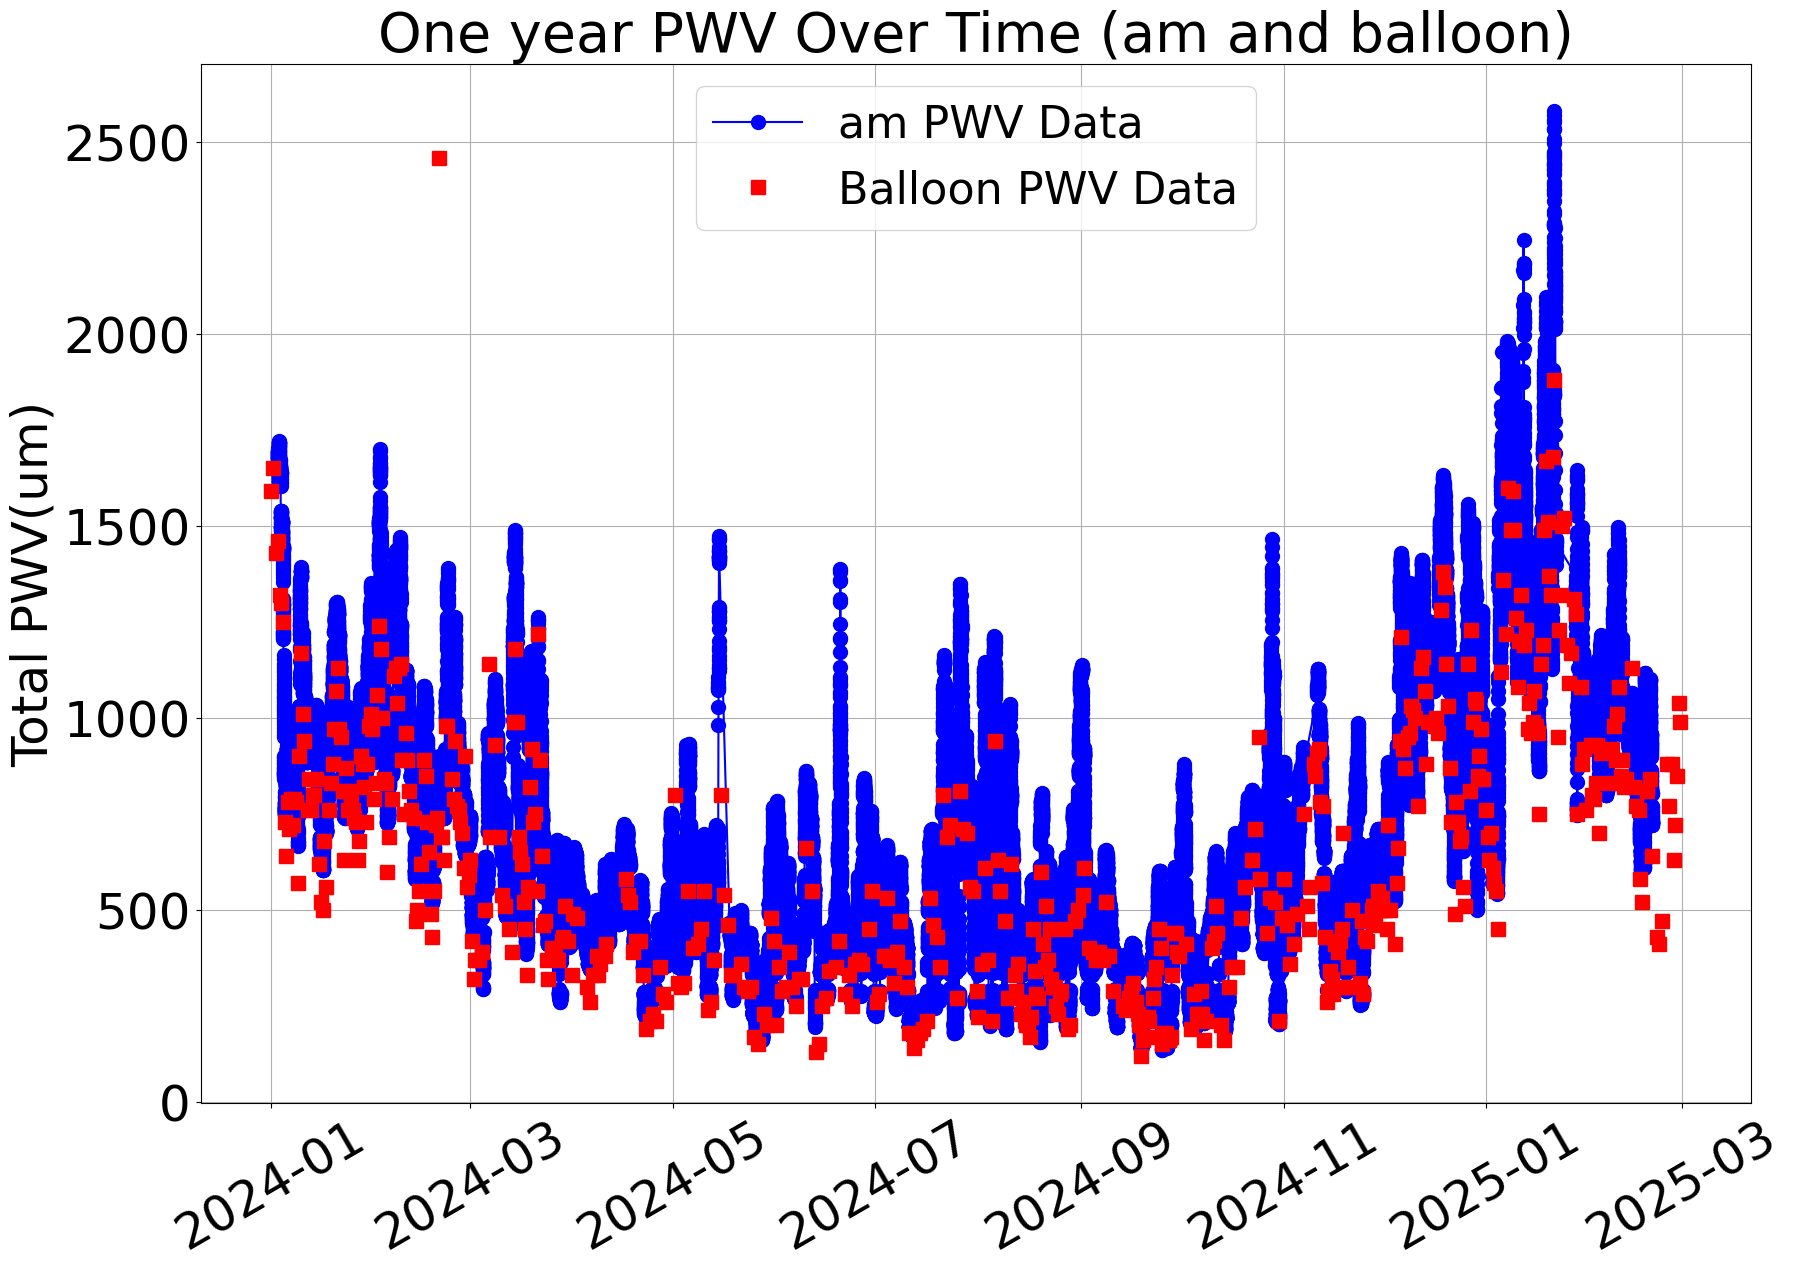

In [1]:
# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units
from siphon.simplewebservice.wyoming import WyomingUpperAir
import os

seasons = ['All']
files = glob.glob('Data/time_pwv_2*.csv')
season = "All_5min"
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []
for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

df_balloon = pd.read_csv('Data/Alldate_balloon_SP.csv', dtype={'TIME': str, 'PWV_TOTAL': str})
df_balloon['TIME'] = pd.to_datetime(df_balloon['Date(YYYYMMDD_HHMMSS)'], format='%Y%m%d_%H%M%S')
df_balloon['PWV_TOTAL'] = df_balloon['PWV(um)'].astype(float)

TIME_balloon = df_balloon['TIME'].tolist()
PWV_TOTAL_balloon = df_balloon['PWV_TOTAL'].tolist()

# plot the data
plt.figure(figsize=(40/2, 27/2))
plt.plot(TIME, PWV_TOTAL_zenith, marker='o', linestyle='-', color='b', markersize=10, label='am PWV Data')
plt.plot(TIME_balloon, PWV_TOTAL_balloon, marker='s', linestyle='None', color='r', markersize=10, label='Balloon PWV Data')
plt.title(f'One year PWV Over Time (am and balloon)', fontsize=40)
plt.ylabel('Total PWV(um)', fontsize=36)
plt.xticks(rotation=30, fontsize=36)
plt.yticks(fontsize=36)
plt.grid()
plt.legend(loc='best', fontsize=32)
plt.savefig(f'Data/plots/{season}_pwv_over_time_Balloon.png', dpi=450)
plt.savefig(f'Data/plots/{season}_pwv_over_time_Balloon.pdf')
plt.show()
plt.close()

